In [24]:
from tracepro.app import TP_app
from tracepro.element import Element
from tracepro.source import Source

import numpy as np
import matplotlib.pyplot as plt

### New file

In [25]:
working_path =r"C:\Software\tracepro\resultados\ejemplo_basico_minimet"
tp_file_name = "ejemplo_basico_minimet"

tp = TP_app(macro_path=working_path, macro_name='ejemplo_basico_minimet')
tp.new_file(file_name=tp_file_name, tp_path=working_path)

In [26]:
# tp.delete_macro()

### Parameters

In [27]:
angle = 45
y = 4
z = np.tan(np.deg2rad(angle)) * y

print(z)

3.9999999999999996


### Emisor

In [28]:
em_dim = (1, 1, 0.5) # x, y, z
em_center = (0, 0, 0)
em_rotation = (45, 0, 0)
em_oriention = ("angles", em_rotation, "")
degrees = True

emisor = Element("emisor") 
em = emisor.block(dimensions=em_dim, center=em_center, orientation_method=em_oriention, degrees=degrees)
tp.add_function(em)

fuente = Source("fuente", source_num=1)
fu = fuente.add_surface_source(object_name=emisor.name, surface_num=1, emission_type="irradiance", emission=1, units="radiometric", ang_dist=2, flux=1000)
tp.add_function(fu)

wavelength = fuente.set_wavelength(wavelength=(0.555, 1))
tp.add_function(wavelength)

### Espejo

In [29]:
mir_z = z - (em_dim[2] / 2)

mir_dim = (2, 2, 0.5) # x, y, z
mir_center = (0, -y, mir_z)
mir_rotation = (90, 0, 0)
mir_oriention = ("angles", mir_rotation, "")


mirror = Element("espejo")
mir = mirror.block(dimensions=mir_dim, center=mir_center, orientation_method=mir_oriention, degrees=degrees)
tp.add_function(mir)

tp.apply_property(object_name=mirror.name, surface_num=0, property=("default", "mirror"))
tp.name_surfaces(object_name=mirror.name, surface_num=0, name="Superficie reflectante")

### Detector

In [30]:
det_z = mir_z * 2

det_dim = (1, 1, 0.5) # x, y, z
det_center = (0, 0, det_z)
det_rotation = (-angle, 0, 0)
det_oriention = ("angles", det_rotation, "")

detector = Element("detector")
det = detector.block(dimensions=det_dim, center=det_center, orientation_method=det_oriention, degrees=degrees)
tp.add_function(det)

tp.apply_property(object_name=detector.name, surface_num=0, property=("default", "perfect absorber"))
tp.name_surfaces(object_name=detector.name, surface_num=0, name="Plano de deteccion")

### Raytrace

In [31]:
raytrace = Source.raytrace()
tp.add_function(raytrace)

tp.select_detection_surface(object_name=detector.name, surface_num=0)
irradiance = fuente.irradiance_analysis(ray_type="absorbed", smooth=True)
tp.add_function(irradiance)
tp.save_file(file_name=tp_file_name, tp_path=working_path)
tp.execute(graphic_window=True)

Successfully completed


''

### Desplazamiento vertical en y:

In [32]:
y_distances = np.linspace((-y + 0.5), (-y - 0.5), 10)

for i, y_dist in enumerate(y_distances):
    tp.move_object(object_name=mirror.name, mode="absolute", distance=(0, y_dist, mir_z))

    raytrace = Source.raytrace()
    tp.add_function(raytrace)

    tp.select_detection_surface(object_name=detector.name, surface_num=0)
    irradiance = fuente.irradiance_analysis(ray_type="absorbed", smooth=True)
    tp.add_function(irradiance)
    tp.save_irradiance_map(save_path=working_path, file_name=f"map_{i+1}", extension="txt")

tp.save_file(file_name="ejemplo_basico_despl", tp_path=working_path)
# tp.execute()

### Desplazamiento angular del espejo:

In [33]:
# Desplazamos el espejo a su posición original:
tp.move_object(object_name=mirror.name, mode="absolute", distance=(0, -y, mir_z))

x_angles = np.ones(10) * 0.5

for i, x_angle in enumerate(x_angles):
    tp.rotate_object(object_name=mirror.name, angle=x_angle, axis_type=2, degrees=True, rotation_point=(0, 0, 0), object_ref=True)

    raytrace = Source.raytrace()
    tp.add_function(raytrace)

    tp.select_detection_surface(object_name=detector.name, surface_num=0)
    irradiance = fuente.irradiance_analysis(ray_type="absorbed", smooth=True)
    tp.add_function(irradiance)
    tp.save_irradiance_map(save_path=working_path, file_name=f"map_r_{i+1}", extension="txt")

tp.save_file(file_name="ejemplo_basico_despa", tp_path=working_path)
tp.execute(graphic_window=True)

Successfully completed


''

### Mapas de irradiancia:

In [34]:
num_distances = len(y_distances)
file_names = []

for i, file in enumerate(y_distances):
    name = f"map_{i + 1}"
    file_names.append(name)

irradiance_map_data = tp.txt_map2array(txt_path=working_path, num_files=len(y_distances), file_name=file_names)

In [35]:
print(irradiance_map_data.shape)

(128, 128, 10)


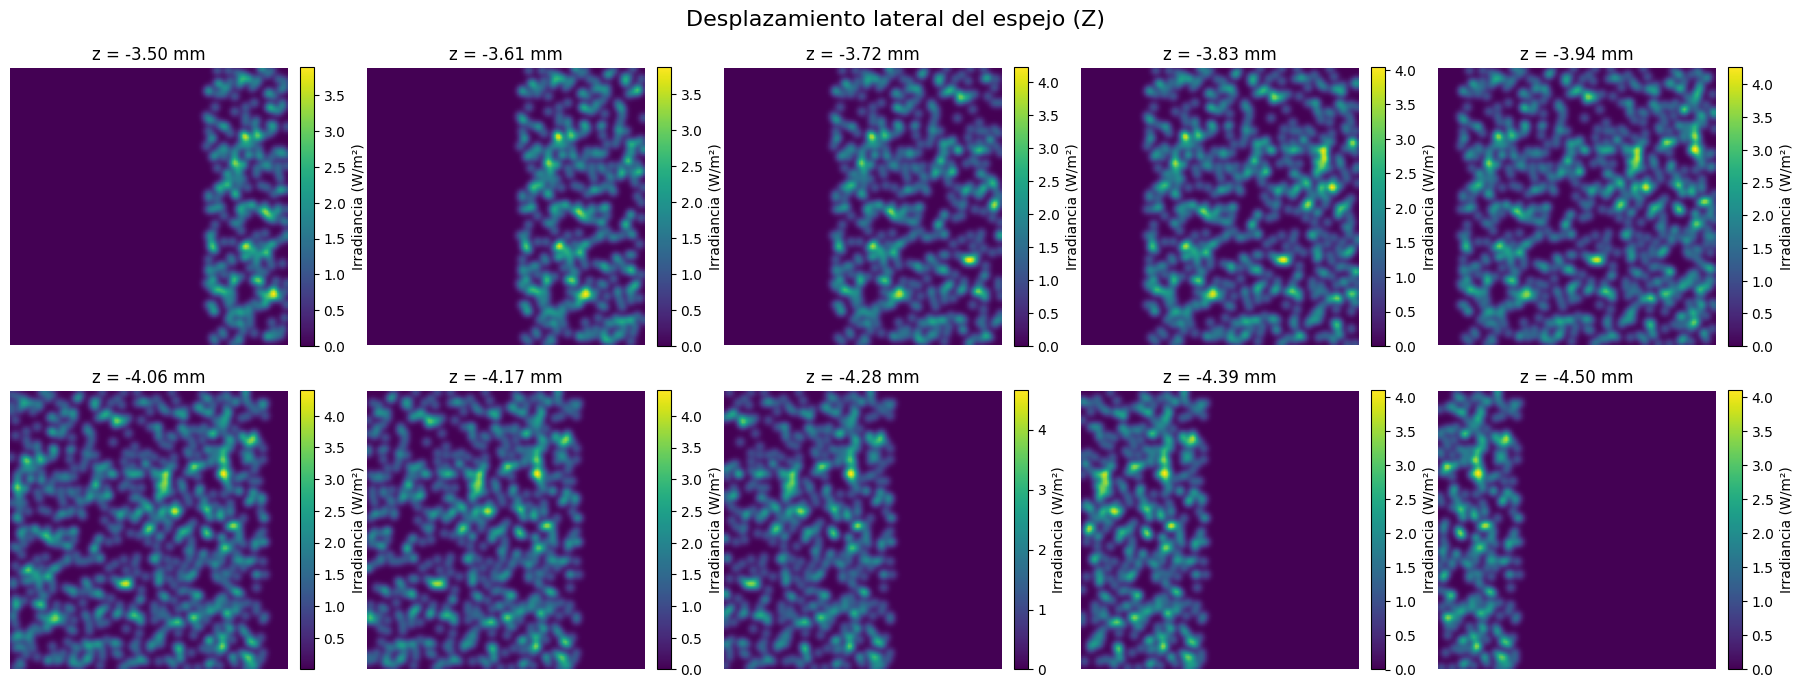

In [36]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for i in range(10):
    ax = axes[i // 5, i % 5]   # fila y columna del subplot
    im = ax.imshow(irradiance_map_data[:, :, i], origin="lower")
    ax.set_title(f"z = {(y_distances[i]):.2f} mm")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Irradiancia (W/m²)")

plt.suptitle("Desplazamiento lateral del espejo (Z)", fontsize=16)
plt.tight_layout()
plt.show()

### Mapas de irradiancia

In [37]:
# time.sleep(20)
num_angles = len(x_angles)
file_names_2 = []

for i, file in enumerate(x_angles):
    name = f"map_r_{i + 1}"
    file_names_2.append(name)

irradiance_map_data_2 = tp.txt_map2array(txt_path=working_path, num_files=num_angles, file_name=file_names_2)

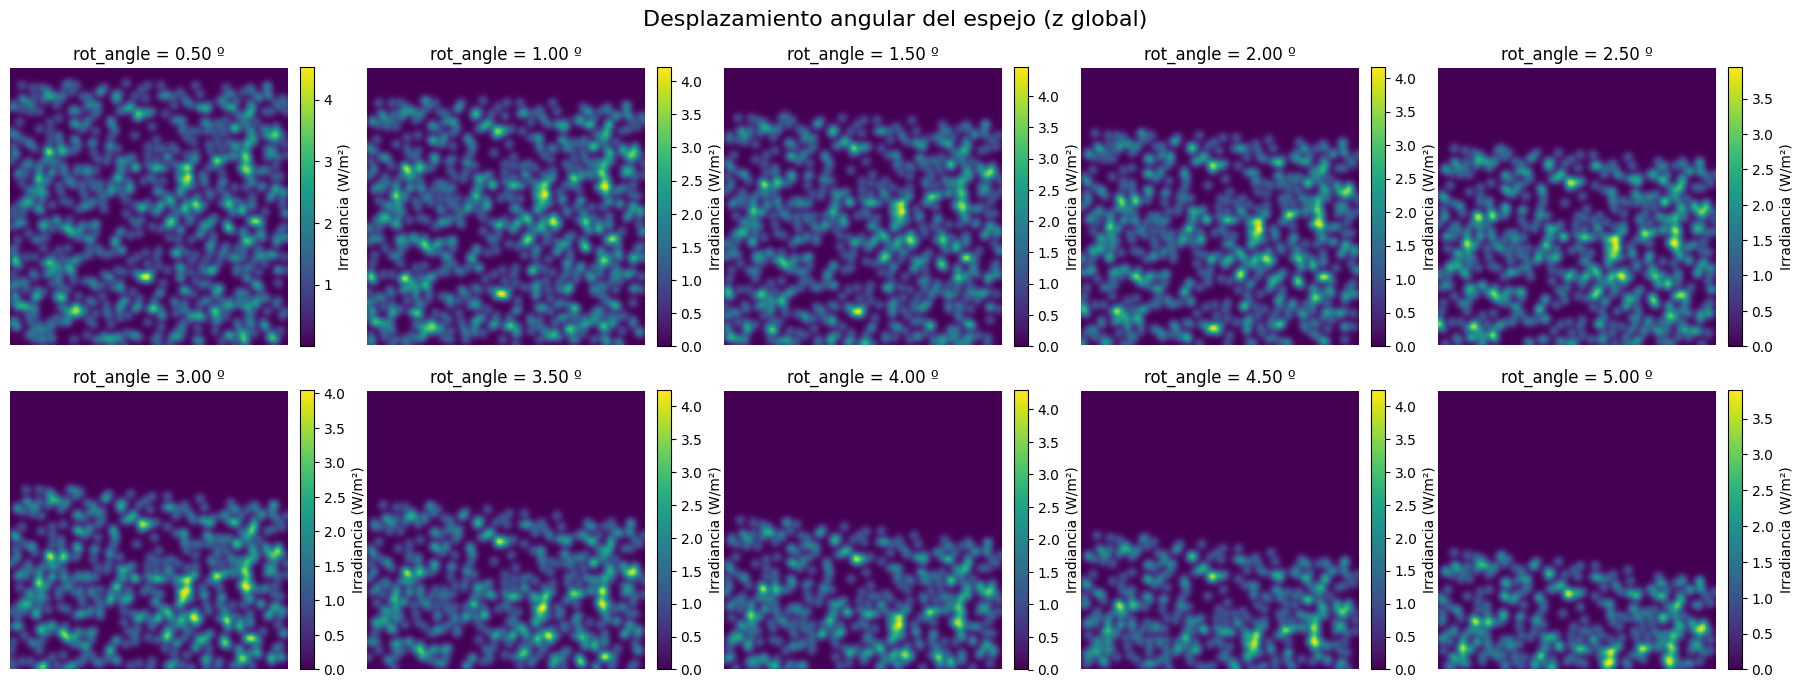

In [38]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
angle = 0

for i in range(10):
    ax = axes[i // 5, i % 5]   # fila y columna del subplot
    im = ax.imshow(irradiance_map_data_2[:, :, i], origin="lower")
    angle += x_angles[i]
    z_angle = mir_rotation[2] + angle
    ax.set_title(f"rot_angle = {(z_angle):.2f} º")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Irradiancia (W/m²)")

plt.suptitle("Desplazamiento angular del espejo (z global)", fontsize=16)
plt.tight_layout()
plt.show()

In [39]:
# tp.execute()